# Visualizing Honey Production 🍯 🐝

The dataset displays honey production in many U.S. states. Features include number of colonies, yield per colony, total production, stocks, price per pound, and value of the honey produced in each state from 1998-2012.

## Scatterplots

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

honey = pd.read_csv("../../data/honey.csv")
honey.head()

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,AR,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,CA,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,CO,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998


Create a basic `scatterplot` to show the relationship between price per pound of honey and its U.S. state.<br/>
Make the y-axis tall enough to display all the states:

In [3]:
def format_axis():
    """Display a grid with white lines below the plot,
    set the Axes face color to a gray bluish one and remove
    the lines denoting the data boundaries."""
    plt.grid(axis="both", c="white")
    plt.gca().set_facecolor("#EAEAF2")
    plt.gca().set_axisbelow(True)

    # Hide the lines denoting the data area boundaries.
    for _, spine in plt.gca().spines.items():
        spine.set_visible(False)

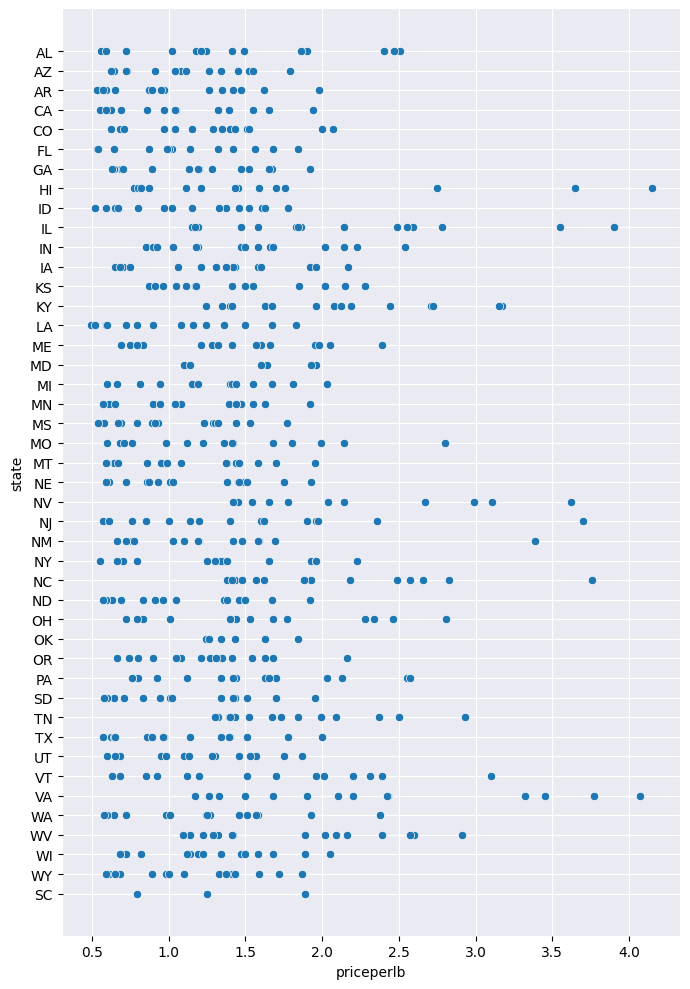

In [4]:
sns.relplot(data=honey, x="priceperlb", y="state", height=10, aspect=0.7)
format_axis()

Show the same data with a honey color scheme to show how the price evolves over the years.<br/>
You can do this by adding a `hue` parameter to show the change year over year:

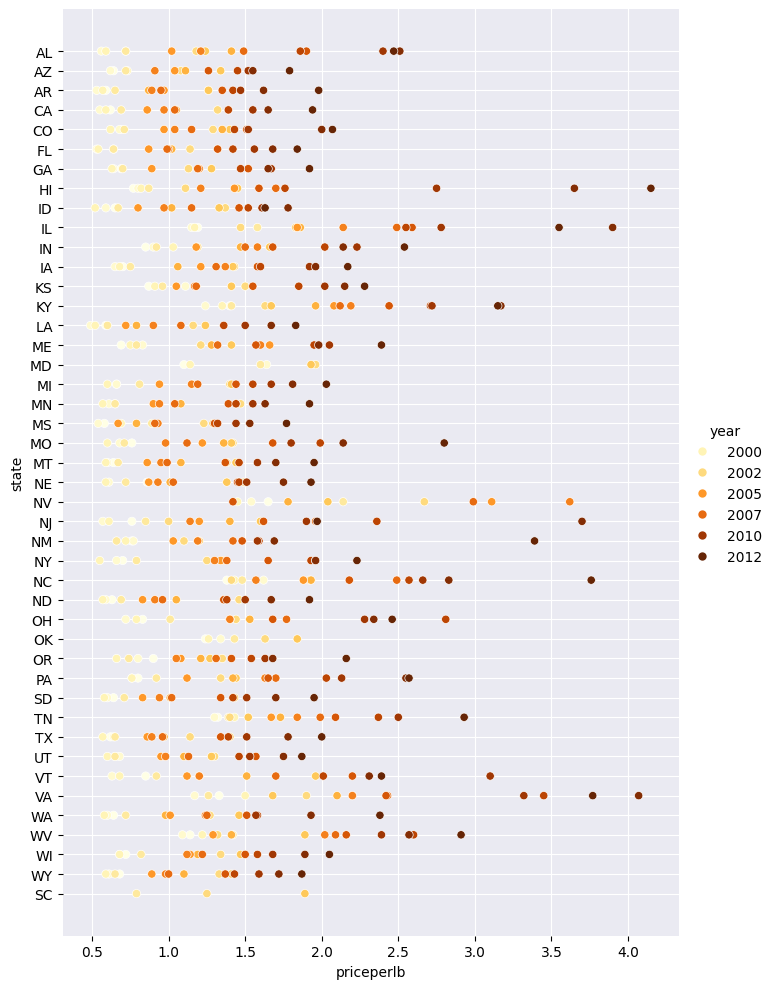

In [5]:
# A list of availabel color palettes to use:
# rocket, mako, icefire, flare, crest, magma, viridis, cubehelix, Blues, YlOrBr, Spectral, coolwarm
sns.relplot(data=honey, x="priceperlb", y="state", hue="year", height=10, aspect=0.7, palette="YlOrBr")
format_axis()

Obviously, there's a strong progression over the years in terms of honey price per pound.<br/>
To verify this, we pick a random state e.g. Arizona where we can see the pattern of price increases over the years.

In [6]:
honey.loc[honey.state == "AZ"]

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
44,AZ,52000.0,62,3224000.0,1548000.0,0.62,1999000.0,1999
87,AZ,40000.0,59,2360000.0,1322000.0,0.73,1723000.0,2000
130,AZ,43000.0,59,2537000.0,1142000.0,0.72,1827000.0,2001
174,AZ,38000.0,63,2394000.0,1197000.0,1.08,2586000.0,2002
218,AZ,35000.0,72,2520000.0,983000.0,1.34,3377000.0,2003
262,AZ,32000.0,55,1760000.0,774000.0,1.11,1954000.0,2004
303,AZ,36000.0,50,1800000.0,720000.0,1.04,1872000.0,2005
344,AZ,30000.0,65,1950000.0,839000.0,0.91,1775000.0,2006
385,AZ,30000.0,64,1920000.0,902000.0,1.26,2419000.0,2007


Another way to visualize the progression is to use size, rather than color.<br/>
Below we show an increase of price by an increase in dot circumference.

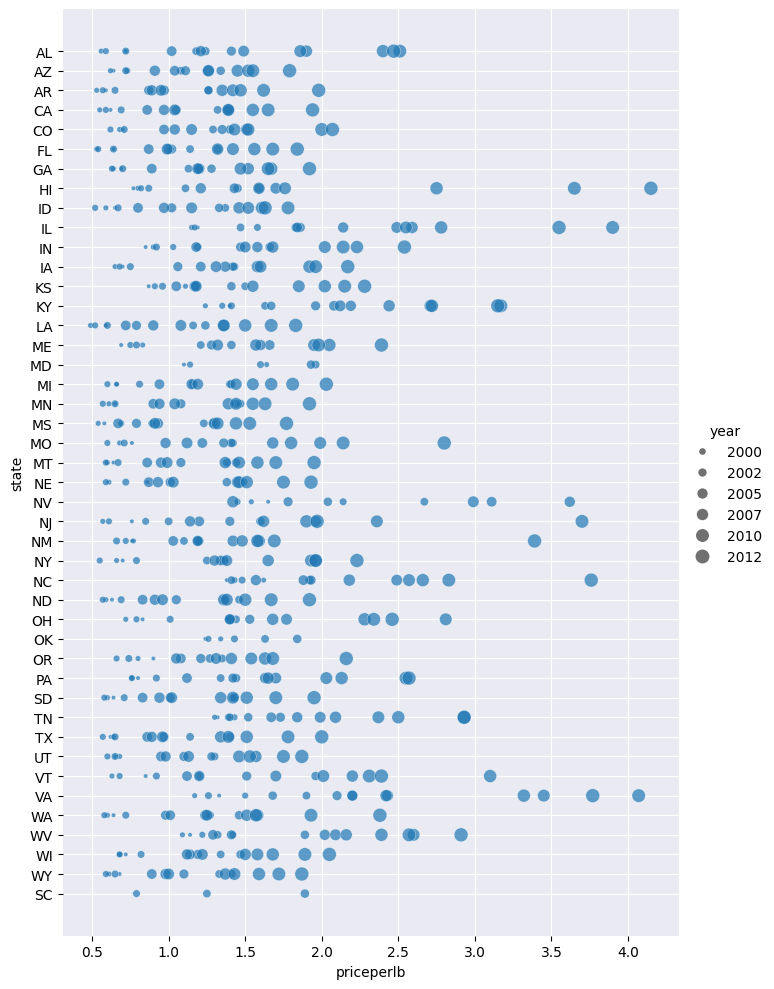

In [7]:
sns.relplot(data=honey, x="priceperlb", y="state", size="year", sizes=(10, 100), height=10, aspect=0.7, alpha=0.7)
format_axis()

To discover a correlation between some of the variables in this dataset, let's explore some **line charts**.

## Line Charts

**Question**: Is there a definite rise in the price of honey year over year?<br/>
To easily discover that, we create a single **line chart**.

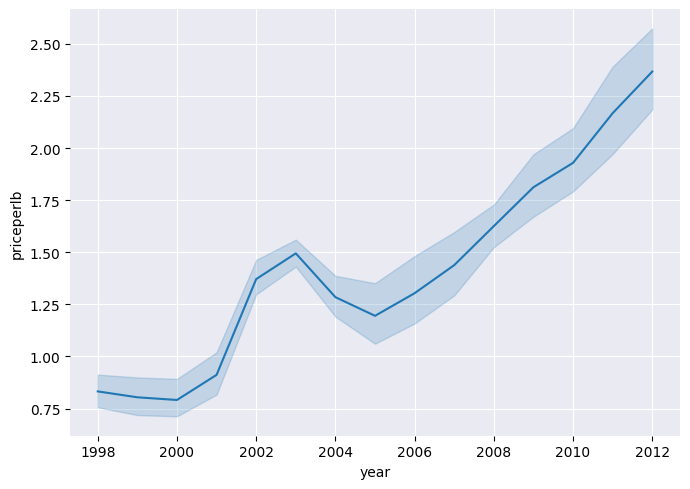

In [8]:
# errorbar=None does not calculate the 95% confidence intervals around each mean value.
# remove it to see the difference (faster rendering).
sns.relplot(data=honey, x="year", y="priceperlb", kind="line", aspect=1.4)
format_axis()

**Answer**: Yes, with some exceptions around the year 2003

**Question**: In 2003 can we also see a spike in the honey supply? What if we look at total production year over year?

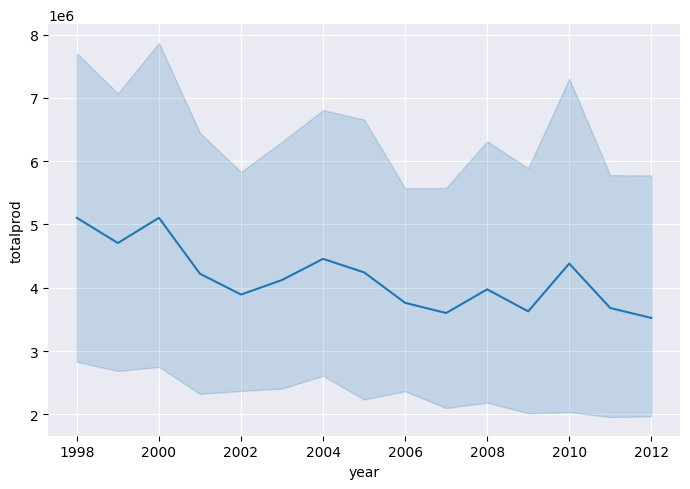

In [9]:
sns.relplot(data=honey, x="year", y="totalprod", kind="line", aspect=1.4)
format_axis()

**Answer**: Not really. If you look at total production, it actually seems to have increased in that particular year, even though generally speaking, production of honey is in decline during the years 1998-2012.

**Question**: In that case, what could have caused that spike in the price of honey around 2003?

## Facet Grids

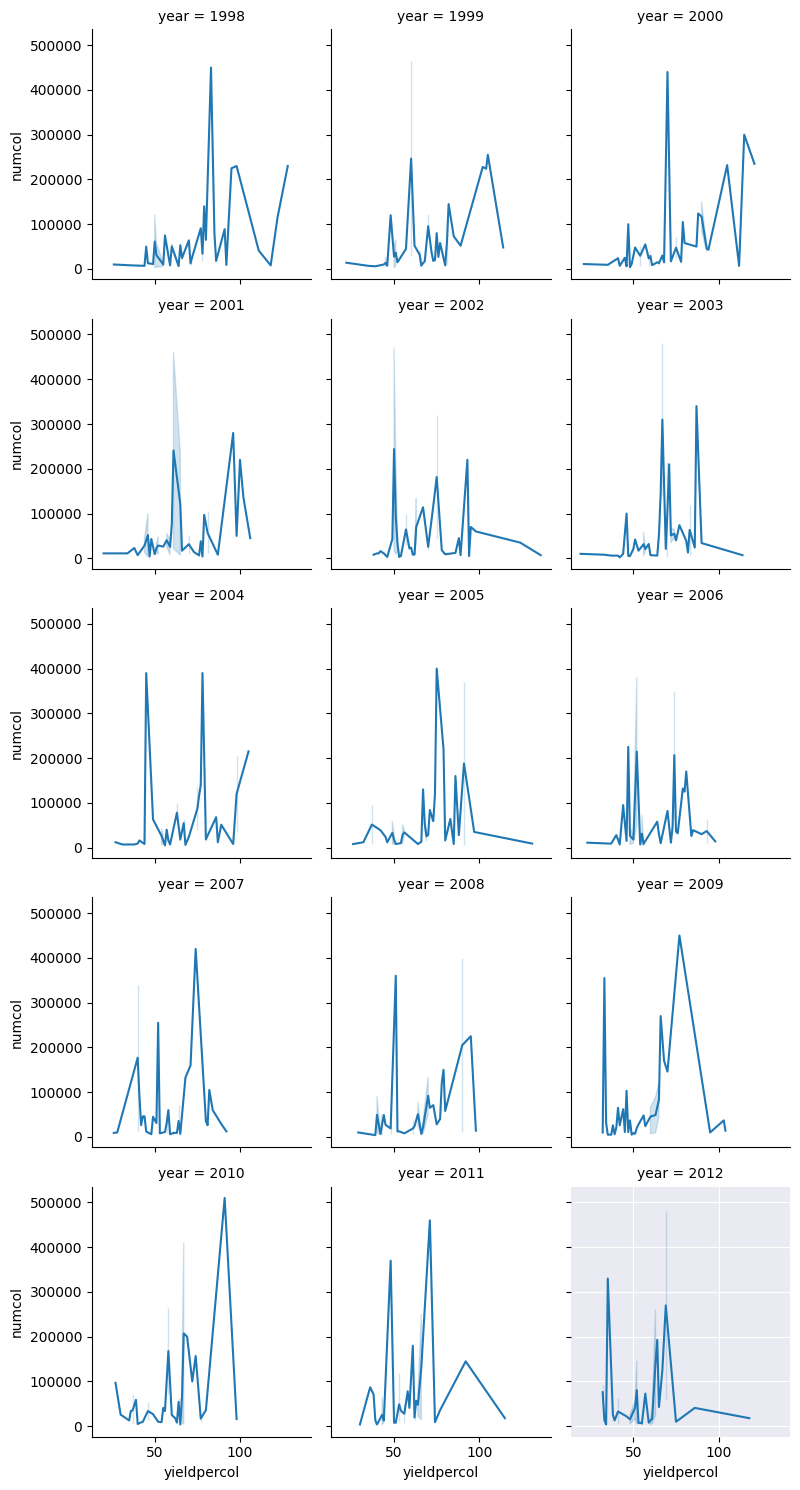

In [10]:
# sns.set_style("darkgrid")
g = sns.relplot(data=honey, x="yieldpercol", y="numcol", col="year", col_wrap=3, kind="line", height=3, aspect=0.9)

for ax in g.axes.flatten():
    format_axis()

## Dual-line Plots

Try a multiline plot by **superimposing** two lineplots on top of each other, using Seaborn's `despine` to remove their top and right spines, and using `ax.twinx` derived from matplotlib. Twinx allows a chart to share the x-axis and display two y-axes. So, display the yield per colony and number of colonies, superimposed.

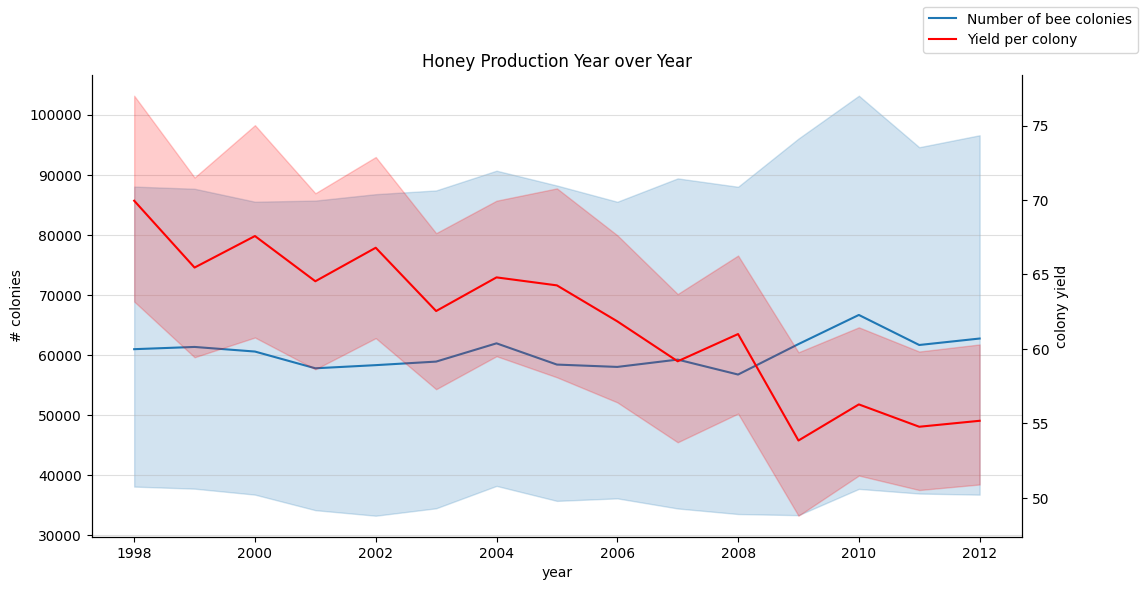

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

lineplot = sns.lineplot(data=honey, x=honey.year, y=honey.numcol, label="Number of bee colonies", legend=False)
sns.despine()
plt.ylabel("# colonies")
plt.title("Honey Production Year over Year")

ax2 = ax.twinx()
lineplot2 = sns.lineplot(x=honey.year, y=honey.yieldpercol, ax=ax2, color="r", label="Yield per colony", legend=False)
sns.despine(right=False)
plt.ylabel("colony yield")
ax.figure.legend()
ax.grid(axis="y", alpha=0.4)

An obvious result from this multiline graph is that while the number of bee colonies is approximately stable, the yield per colony decreases year by year.